#### Bottom_left

In [2]:
# === Resumen por bin + gráficas (barras y 3D) ===
import os
os.chdir(r"C:\Users\jaime\OneDrive - Universidad de la Sabana\Desktop\Jaime Pesca\MIT\GCLOG\Capstone project\SIMPAC-2024-311-main - 2 - testing")

from deeppack3d import deeppack3d
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ---- Parámetros de corrida ----
METHOD = 'bl'              # <--- CAMBIADO: antes era 'rl'
K = 200
DATA_MODE = 'file'         # usamos tu archivo de datos
PATH = './Input_worst_div10_ceil.txt'       # asegúrate de que este archivo exista ahí
N_ITERS = 200              # solo se usa si DATA_MODE == 'generated'
SEED = 42                  # solo se usa si DATA_MODE == 'generated'

# (Opcional) tamaño del contenedor/pallet (W,H,D)
CONTAINER_SIZE = None      # None => se infiere por bounding box

# ---- Recolectar colocaciones por bin ----
bins = []               # lista de bins; cada bin es una lista de items
current_bin_items = None

gen_kwargs = dict(data=DATA_MODE, verbose=0)
if DATA_MODE == 'file':
    gen_kwargs['path'] = PATH
else:
    gen_kwargs['n_iterations'] = N_ITERS
    gen_kwargs['seed'] = SEED

for result in deeppack3d(METHOD, K, **gen_kwargs):
    if result is None:
        # empieza un nuevo bin
        current_bin_items = []
        bins.append(current_bin_items)
        continue
    bin_id, (x,y,z), (w,h,d), meta = result
    if current_bin_items is None:
        current_bin_items = []
        bins.append(current_bin_items)
    current_bin_items.append((x,y,z,w,h,d))

num_bins = len(bins)
print(f"🧱 Bins detectados: {num_bins}")

# ---- Utilidad por bin ----
def bin_utilization(items, container_size=None):
    """Devuelve (utilizacion, used_volume, container_volume, (W,H,D) usado)"""
    if not items:
        return 0.0, 0.0, 0.0, (0,0,0)
    used_volume = sum(w*h*d for (_,_,_,w,h,d) in items)
    if container_size is None:
        # inferir por bounding box de lo empacado
        max_x = max(x+w for (x,y,z,w,h,d) in items)
        max_y = max(y+h for (x,y,z,w,h,d) in items)
        max_z = max(z+d for (x,y,z,w,h,d) in items)
        W,H,D = max_x, max_y, max_z
    else:
        W,H,D = container_size
    container_volume = max(1, W*H*D)  # evita div/0
    return (used_volume / container_volume, used_volume, container_volume, (W,H,D))

utilizations = []
sizes_used = []
for i, items in enumerate(bins):
    u, used_v, cont_v, sz = bin_utilization(items, CONTAINER_SIZE)
    utilizations.append(u)
    sizes_used.append(sz)
    print(f"Bin {i}: util={u:.3f}  used_vol={used_v:.0f}  cont_vol={cont_v:.0f}  size={sz}")

# ---- Gráfico de barras: utilización por bin ----
plt.figure(figsize=(8,4))
plt.bar(range(len(utilizations)), utilizations)
plt.xlabel("Bin")
plt.ylabel("Utilización (0–1)")
plt.title(f"Utilización por bin — {METHOD.upper()}  k={K}")
plt.ylim(0, 1.0)
plt.show()

# ---- 3D del bin que elijas ----
BIN_TO_PLOT = 40  # cambia el índice para ver otro bin

def draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35):
    # Si por algún error vino una caja "vacía", no la dibujes
    if w <= 0 or h <= 0 or d <= 0:
        return

    X = [x, x+w]; Y = [y, y+h]; Z = [z, z+d]
    faces = [
        [(X[0],Y[0],Z[0]), (X[1],Y[0],Z[0]), (X[1],Y[1],Z[0]), (X[0],Y[1],Z[0])],
        [(X[0],Y[0],Z[1]), (X[1],Y[0],Z[1]), (X[1],Y[1],Z[1]), (X[0],Y[1],Z[1])],
        [(X[0],Y[0],Z[0]), (X[1],Y[0],Z[0]), (X[1],Y[0],Z[1]), (X[0],Y[0],Z[1])],
        [(X[0],Y[1],Z[0]), (X[1],Y[1],Z[0]), (X[1],Y[1],Z[1]), (X[0],Y[1],Z[1])],
        [(X[0],Y[0],Z[0]), (X[0],Y[1],Z[0]), (X[0],Y[1],Z[1]), (X[0],Y[0],Z[1])],
        [(X[1],Y[0],Z[0]), (X[1],Y[1],Z[0]), (X[1],Y[1],Z[1]), (X[1],Y[0],Z[1])],
    ]
    poly = Poly3DCollection(faces, edgecolor='k', alpha=alpha)
    ax.add_collection3d(poly)

def get_axis_limits(items, fallback=(1,1,1)):
    if not items:
        return (0,1),(0,1),(0,1)
    max_x = max(x+w for (x,y,z,w,h,d) in items)
    max_y = max(y+h for (x,y,z,w,h,d) in items)
    max_z = max(z+d for (x,y,z,w,h,d) in items)
    return (0, max(max_x, fallback[0])), (0, max(max_y, fallback[1])), (0, max(max_z, fallback[2]))

items = bins[BIN_TO_PLOT] if BIN_TO_PLOT < num_bins else []
(W,H,D) = sizes_used[BIN_TO_PLOT] if BIN_TO_PLOT < num_bins else (1,1,1)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# dibuja contenedor solo con líneas (sin Poly3DCollection para evitar el bug)
def draw_container_wire(ax, W,H,D):
    edges = [
        ((0,0,0),(W,0,0)), ((W,0,0),(W,H,0)),
        ((W,H,0),(0,H,0)), ((0,H,0),(0,0,0)),
        ((0,0,D),(W,0,D)), ((W,0,D),(W,H,D)),
        ((W,H,D),(0,H,D)), ((0,H,D),(0,0,D)),
        ((0,0,0),(0,0,D)), ((W,0,0),(W,0,D)),
        ((W,H,0),(W,H,D)), ((0,H,0),(0,H,D)),
    ]
    for (x1,y1,z1),(x2,y2,z2) in edges:
        ax.plot([x1,x2],[y1,y2],[z1,z2], linewidth=1.2)

# dibuja contenedor inferido o indicado
draw_container_wire(ax, W,H,D)

# dibuja cajas (limita cantidad si hay muchas)
for (x,y,z,w,h,d) in items[:300]:
    draw_cuboid(ax, x,y,z,w,h,d, alpha=0.35)

# ejes
(xmin,xmax),(ymin,ymax),(zmin,zmax) = get_axis_limits(items, (W,H,D))
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax); ax.set_zlim(zmin, zmax)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.view_init(elev=20, azim=35)
plt.title(f"Bin {BIN_TO_PLOT} — util={utilizations[BIN_TO_PLOT]:.3f}")
plt.show()


KeyboardInterrupt: 

#### Best_short_side_fit

🧱 Bins detectados: 44
Bin 0: util=0.785  used_vol=18841  cont_vol=24000  size=(25, 32, 30)
Bin 1: util=0.803  used_vol=19281  cont_vol=24000  size=(25, 32, 30)
Bin 2: util=0.788  used_vol=18913  cont_vol=24000  size=(25, 32, 30)
Bin 3: util=0.806  used_vol=19336  cont_vol=24000  size=(25, 32, 30)
Bin 4: util=0.755  used_vol=18120  cont_vol=24000  size=(25, 32, 30)
Bin 5: util=0.720  used_vol=17282  cont_vol=24000  size=(25, 32, 30)
Bin 6: util=0.754  used_vol=18091  cont_vol=24000  size=(25, 32, 30)
Bin 7: util=0.809  used_vol=19413  cont_vol=24000  size=(25, 32, 30)
Bin 8: util=0.798  used_vol=19155  cont_vol=24000  size=(25, 32, 30)
Bin 9: util=0.806  used_vol=19345  cont_vol=24000  size=(25, 32, 30)
Bin 10: util=0.745  used_vol=17884  cont_vol=24000  size=(25, 32, 30)
Bin 11: util=0.789  used_vol=18928  cont_vol=24000  size=(25, 32, 30)
Bin 12: util=0.777  used_vol=18659  cont_vol=24000  size=(25, 32, 30)
Bin 13: util=0.786  used_vol=18857  cont_vol=24000  size=(25, 32, 30)
Bin 14: 

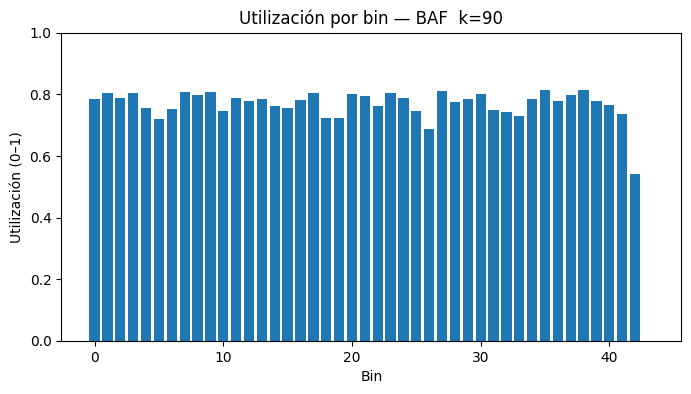

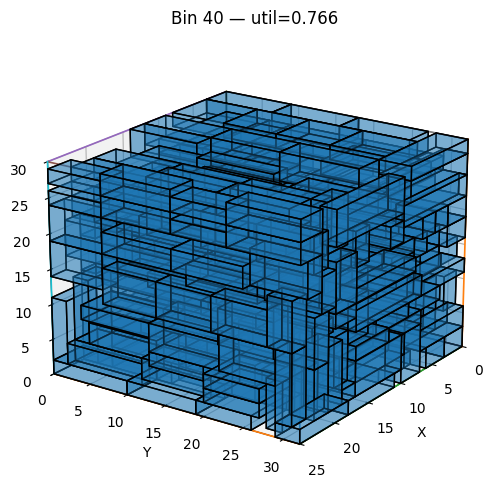

In [2]:
# === Resumen por bin + gráficas (barras y 3D) ===
import os
os.chdir(r"C:\Users\jaime\OneDrive - Universidad de la Sabana\Desktop\Jaime Pesca\MIT\GCLOG\Capstone project\SIMPAC-2024-311-main - 2 - testing")

from deeppack3d import deeppack3d
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ---- Parámetros de corrida ----
METHOD = 'baf'              # <--- CAMBIADO: antes era 'rl'
K = 90
DATA_MODE = 'file'         # usamos tu archivo de datos
PATH = './Input_worst_div10_ceil.txt'       # asegúrate de que este archivo exista ahí
N_ITERS = 200              # solo se usa si DATA_MODE == 'generated'
SEED = 42                  # solo se usa si DATA_MODE == 'generated'

# (Opcional) tamaño del contenedor/pallet (W,H,D)
CONTAINER_SIZE = None      # None => se infiere por bounding box

# ---- Recolectar colocaciones por bin ----
bins = []               # lista de bins; cada bin es una lista de items
current_bin_items = None

gen_kwargs = dict(data=DATA_MODE, verbose=0)
if DATA_MODE == 'file':
    gen_kwargs['path'] = PATH
else:
    gen_kwargs['n_iterations'] = N_ITERS
    gen_kwargs['seed'] = SEED

for result in deeppack3d(METHOD, K, **gen_kwargs):
    if result is None:
        # empieza un nuevo bin
        current_bin_items = []
        bins.append(current_bin_items)
        continue
    bin_id, (x,y,z), (w,h,d), meta = result
    if current_bin_items is None:
        current_bin_items = []
        bins.append(current_bin_items)
    current_bin_items.append((x,y,z,w,h,d))

num_bins = len(bins)
print(f"🧱 Bins detectados: {num_bins}")

# ---- Utilidad por bin ----
def bin_utilization(items, container_size=None):
    """Devuelve (utilizacion, used_volume, container_volume, (W,H,D) usado)"""
    if not items:
        return 0.0, 0.0, 0.0, (0,0,0)
    used_volume = sum(w*h*d for (_,_,_,w,h,d) in items)
    if container_size is None:
        # inferir por bounding box de lo empacado
        max_x = max(x+w for (x,y,z,w,h,d) in items)
        max_y = max(y+h for (x,y,z,w,h,d) in items)
        max_z = max(z+d for (x,y,z,w,h,d) in items)
        W,H,D = max_x, max_y, max_z
    else:
        W,H,D = container_size
    container_volume = max(1, W*H*D)  # evita div/0
    return (used_volume / container_volume, used_volume, container_volume, (W,H,D))

utilizations = []
sizes_used = []
for i, items in enumerate(bins):
    u, used_v, cont_v, sz = bin_utilization(items, CONTAINER_SIZE)
    utilizations.append(u)
    sizes_used.append(sz)
    print(f"Bin {i}: util={u:.3f}  used_vol={used_v:.0f}  cont_vol={cont_v:.0f}  size={sz}")

# ---- Gráfico de barras: utilización por bin ----
plt.figure(figsize=(8,4))
plt.bar(range(len(utilizations)), utilizations)
plt.xlabel("Bin")
plt.ylabel("Utilización (0–1)")
plt.title(f"Utilización por bin — {METHOD.upper()}  k={K}")
plt.ylim(0, 1.0)
plt.show()

# ---- 3D del bin que elijas ----
BIN_TO_PLOT = 40  # cambia el índice para ver otro bin

def draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35):
    # Si por algún error vino una caja "vacía", no la dibujes
    if w <= 0 or h <= 0 or d <= 0:
        return

    X = [x, x+w]; Y = [y, y+h]; Z = [z, z+d]
    faces = [
        [(X[0],Y[0],Z[0]), (X[1],Y[0],Z[0]), (X[1],Y[1],Z[0]), (X[0],Y[1],Z[0])],
        [(X[0],Y[0],Z[1]), (X[1],Y[0],Z[1]), (X[1],Y[1],Z[1]), (X[0],Y[1],Z[1])],
        [(X[0],Y[0],Z[0]), (X[1],Y[0],Z[0]), (X[1],Y[0],Z[1]), (X[0],Y[0],Z[1])],
        [(X[0],Y[1],Z[0]), (X[1],Y[1],Z[0]), (X[1],Y[1],Z[1]), (X[0],Y[1],Z[1])],
        [(X[0],Y[0],Z[0]), (X[0],Y[1],Z[0]), (X[0],Y[1],Z[1]), (X[0],Y[0],Z[1])],
        [(X[1],Y[0],Z[0]), (X[1],Y[1],Z[0]), (X[1],Y[1],Z[1]), (X[1],Y[0],Z[1])],
    ]
    poly = Poly3DCollection(faces, edgecolor='k', alpha=alpha)
    ax.add_collection3d(poly)

def get_axis_limits(items, fallback=(1,1,1)):
    if not items:
        return (0,1),(0,1),(0,1)
    max_x = max(x+w for (x,y,z,w,h,d) in items)
    max_y = max(y+h for (x,y,z,w,h,d) in items)
    max_z = max(z+d for (x,y,z,w,h,d) in items)
    return (0, max(max_x, fallback[0])), (0, max(max_y, fallback[1])), (0, max(max_z, fallback[2]))

items = bins[BIN_TO_PLOT] if BIN_TO_PLOT < num_bins else []
(W,H,D) = sizes_used[BIN_TO_PLOT] if BIN_TO_PLOT < num_bins else (1,1,1)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# dibuja contenedor solo con líneas (sin Poly3DCollection para evitar el bug)
def draw_container_wire(ax, W,H,D):
    edges = [
        ((0,0,0),(W,0,0)), ((W,0,0),(W,H,0)),
        ((W,H,0),(0,H,0)), ((0,H,0),(0,0,0)),
        ((0,0,D),(W,0,D)), ((W,0,D),(W,H,D)),
        ((W,H,D),(0,H,D)), ((0,H,D),(0,0,D)),
        ((0,0,0),(0,0,D)), ((W,0,0),(W,0,D)),
        ((W,H,0),(W,H,D)), ((0,H,0),(0,H,D)),
    ]
    for (x1,y1,z1),(x2,y2,z2) in edges:
        ax.plot([x1,x2],[y1,y2],[z1,z2], linewidth=1.2)

# dibuja contenedor inferido o indicado
draw_container_wire(ax, W,H,D)

# dibuja cajas (limita cantidad si hay muchas)
for (x,y,z,w,h,d) in items[:300]:
    draw_cuboid(ax, x,y,z,w,h,d, alpha=0.35)

# ejes
(xmin,xmax),(ymin,ymax),(zmin,zmax) = get_axis_limits(items, (W,H,D))
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax); ax.set_zlim(zmin, zmax)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.view_init(elev=20, azim=35)
plt.title(f"Bin {BIN_TO_PLOT} — util={utilizations[BIN_TO_PLOT]:.3f}")
plt.show()


#### Best_area_fit

🧱 Bins detectados: 44
Bin 0: util=0.735  used_vol=17638  cont_vol=24000  size=(25, 32, 30)
Bin 1: util=0.834  used_vol=20005  cont_vol=24000  size=(25, 32, 30)
Bin 2: util=0.801  used_vol=19219  cont_vol=24000  size=(25, 32, 30)
Bin 3: util=0.806  used_vol=19348  cont_vol=24000  size=(25, 32, 30)
Bin 4: util=0.765  used_vol=18349  cont_vol=24000  size=(25, 32, 30)
Bin 5: util=0.777  used_vol=18642  cont_vol=24000  size=(25, 32, 30)
Bin 6: util=0.826  used_vol=19813  cont_vol=24000  size=(25, 32, 30)
Bin 7: util=0.774  used_vol=18571  cont_vol=24000  size=(25, 32, 30)
Bin 8: util=0.784  used_vol=18807  cont_vol=24000  size=(25, 32, 30)
Bin 9: util=0.803  used_vol=19275  cont_vol=24000  size=(25, 32, 30)
Bin 10: util=0.797  used_vol=19140  cont_vol=24000  size=(25, 32, 30)
Bin 11: util=0.755  used_vol=18118  cont_vol=24000  size=(25, 32, 30)
Bin 12: util=0.768  used_vol=18441  cont_vol=24000  size=(25, 32, 30)
Bin 13: util=0.822  used_vol=19717  cont_vol=24000  size=(25, 32, 30)
Bin 14: 

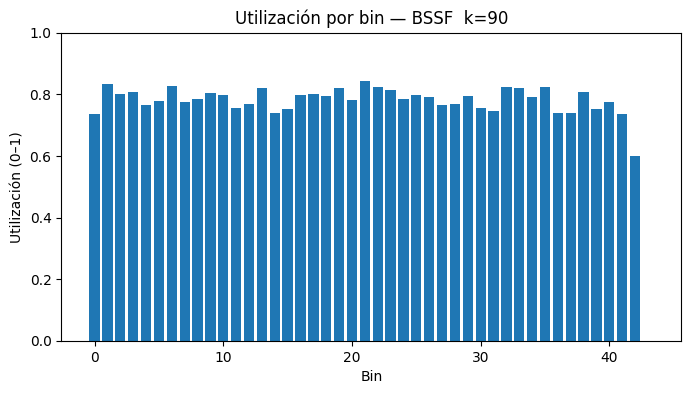

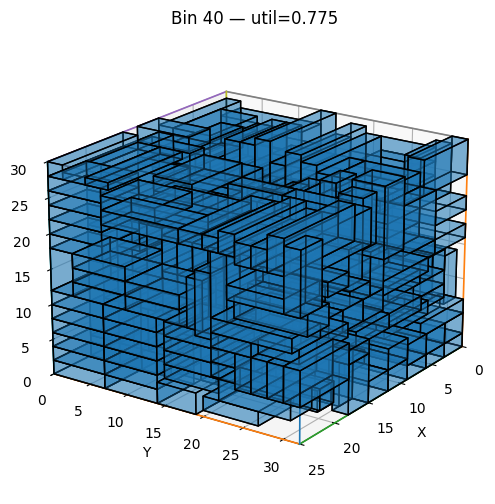

In [3]:
# === Resumen por bin + gráficas (barras y 3D) ===
import os
os.chdir(r"C:\Users\jaime\OneDrive - Universidad de la Sabana\Desktop\Jaime Pesca\MIT\GCLOG\Capstone project\SIMPAC-2024-311-main - 2 - testing")

from deeppack3d import deeppack3d
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ---- Parámetros de corrida ----
METHOD = 'bssf'              # <--- CAMBIADO: antes era 'rl'
K = 90
DATA_MODE = 'file'         # usamos tu archivo de datos
PATH = './Input_worst_div10_ceil.txt'       # asegúrate de que este archivo exista ahí
N_ITERS = 200              # solo se usa si DATA_MODE == 'generated'
SEED = 42                  # solo se usa si DATA_MODE == 'generated'

# (Opcional) tamaño del contenedor/pallet (W,H,D)
CONTAINER_SIZE = None      # None => se infiere por bounding box

# ---- Recolectar colocaciones por bin ----
bins = []               # lista de bins; cada bin es una lista de items
current_bin_items = None

gen_kwargs = dict(data=DATA_MODE, verbose=0)
if DATA_MODE == 'file':
    gen_kwargs['path'] = PATH
else:
    gen_kwargs['n_iterations'] = N_ITERS
    gen_kwargs['seed'] = SEED

for result in deeppack3d(METHOD, K, **gen_kwargs):
    if result is None:
        # empieza un nuevo bin
        current_bin_items = []
        bins.append(current_bin_items)
        continue
    bin_id, (x,y,z), (w,h,d), meta = result
    if current_bin_items is None:
        current_bin_items = []
        bins.append(current_bin_items)
    current_bin_items.append((x,y,z,w,h,d))

num_bins = len(bins)
print(f"🧱 Bins detectados: {num_bins}")

# ---- Utilidad por bin ----
def bin_utilization(items, container_size=None):
    """Devuelve (utilizacion, used_volume, container_volume, (W,H,D) usado)"""
    if not items:
        return 0.0, 0.0, 0.0, (0,0,0)
    used_volume = sum(w*h*d for (_,_,_,w,h,d) in items)
    if container_size is None:
        # inferir por bounding box de lo empacado
        max_x = max(x+w for (x,y,z,w,h,d) in items)
        max_y = max(y+h for (x,y,z,w,h,d) in items)
        max_z = max(z+d for (x,y,z,w,h,d) in items)
        W,H,D = max_x, max_y, max_z
    else:
        W,H,D = container_size
    container_volume = max(1, W*H*D)  # evita div/0
    return (used_volume / container_volume, used_volume, container_volume, (W,H,D))

utilizations = []
sizes_used = []
for i, items in enumerate(bins):
    u, used_v, cont_v, sz = bin_utilization(items, CONTAINER_SIZE)
    utilizations.append(u)
    sizes_used.append(sz)
    print(f"Bin {i}: util={u:.3f}  used_vol={used_v:.0f}  cont_vol={cont_v:.0f}  size={sz}")

# ---- Gráfico de barras: utilización por bin ----
plt.figure(figsize=(8,4))
plt.bar(range(len(utilizations)), utilizations)
plt.xlabel("Bin")
plt.ylabel("Utilización (0–1)")
plt.title(f"Utilización por bin — {METHOD.upper()}  k={K}")
plt.ylim(0, 1.0)
plt.show()

# ---- 3D del bin que elijas ----
BIN_TO_PLOT = 40  # cambia el índice para ver otro bin

def draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35):
    # Si por algún error vino una caja "vacía", no la dibujes
    if w <= 0 or h <= 0 or d <= 0:
        return

    X = [x, x+w]; Y = [y, y+h]; Z = [z, z+d]
    faces = [
        [(X[0],Y[0],Z[0]), (X[1],Y[0],Z[0]), (X[1],Y[1],Z[0]), (X[0],Y[1],Z[0])],
        [(X[0],Y[0],Z[1]), (X[1],Y[0],Z[1]), (X[1],Y[1],Z[1]), (X[0],Y[1],Z[1])],
        [(X[0],Y[0],Z[0]), (X[1],Y[0],Z[0]), (X[1],Y[0],Z[1]), (X[0],Y[0],Z[1])],
        [(X[0],Y[1],Z[0]), (X[1],Y[1],Z[0]), (X[1],Y[1],Z[1]), (X[0],Y[1],Z[1])],
        [(X[0],Y[0],Z[0]), (X[0],Y[1],Z[0]), (X[0],Y[1],Z[1]), (X[0],Y[0],Z[1])],
        [(X[1],Y[0],Z[0]), (X[1],Y[1],Z[0]), (X[1],Y[1],Z[1]), (X[1],Y[0],Z[1])],
    ]
    poly = Poly3DCollection(faces, edgecolor='k', alpha=alpha)
    ax.add_collection3d(poly)

def get_axis_limits(items, fallback=(1,1,1)):
    if not items:
        return (0,1),(0,1),(0,1)
    max_x = max(x+w for (x,y,z,w,h,d) in items)
    max_y = max(y+h for (x,y,z,w,h,d) in items)
    max_z = max(z+d for (x,y,z,w,h,d) in items)
    return (0, max(max_x, fallback[0])), (0, max(max_y, fallback[1])), (0, max(max_z, fallback[2]))

items = bins[BIN_TO_PLOT] if BIN_TO_PLOT < num_bins else []
(W,H,D) = sizes_used[BIN_TO_PLOT] if BIN_TO_PLOT < num_bins else (1,1,1)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# dibuja contenedor solo con líneas (sin Poly3DCollection para evitar el bug)
def draw_container_wire(ax, W,H,D):
    edges = [
        ((0,0,0),(W,0,0)), ((W,0,0),(W,H,0)),
        ((W,H,0),(0,H,0)), ((0,H,0),(0,0,0)),
        ((0,0,D),(W,0,D)), ((W,0,D),(W,H,D)),
        ((W,H,D),(0,H,D)), ((0,H,D),(0,0,D)),
        ((0,0,0),(0,0,D)), ((W,0,0),(W,0,D)),
        ((W,H,0),(W,H,D)), ((0,H,0),(0,H,D)),
    ]
    for (x1,y1,z1),(x2,y2,z2) in edges:
        ax.plot([x1,x2],[y1,y2],[z1,z2], linewidth=1.2)

# dibuja contenedor inferido o indicado
draw_container_wire(ax, W,H,D)

# dibuja cajas (limita cantidad si hay muchas)
for (x,y,z,w,h,d) in items[:300]:
    draw_cuboid(ax, x,y,z,w,h,d, alpha=0.35)

# ejes
(xmin,xmax),(ymin,ymax),(zmin,zmax) = get_axis_limits(items, (W,H,D))
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax); ax.set_zlim(zmin, zmax)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.view_init(elev=20, azim=35)
plt.title(f"Bin {BIN_TO_PLOT} — util={utilizations[BIN_TO_PLOT]:.3f}")
plt.show()


#### Best_long_side_fit

🧱 Bins detectados: 62
Bin 0: util=0.488  used_vol=11708  cont_vol=24000  size=(25, 32, 30)
Bin 1: util=0.565  used_vol=13550  cont_vol=24000  size=(25, 32, 30)
Bin 2: util=0.528  used_vol=12677  cont_vol=24000  size=(25, 32, 30)
Bin 3: util=0.569  used_vol=13646  cont_vol=24000  size=(25, 32, 30)
Bin 4: util=0.554  used_vol=13301  cont_vol=24000  size=(25, 32, 30)
Bin 5: util=0.538  used_vol=12913  cont_vol=24000  size=(25, 32, 30)
Bin 6: util=0.569  used_vol=13666  cont_vol=24000  size=(25, 32, 30)
Bin 7: util=0.570  used_vol=13689  cont_vol=24000  size=(25, 32, 30)
Bin 8: util=0.521  used_vol=12494  cont_vol=24000  size=(25, 32, 30)
Bin 9: util=0.546  used_vol=13106  cont_vol=24000  size=(25, 32, 30)
Bin 10: util=0.565  used_vol=13549  cont_vol=24000  size=(25, 32, 30)
Bin 11: util=0.583  used_vol=13993  cont_vol=24000  size=(25, 32, 30)
Bin 12: util=0.537  used_vol=12878  cont_vol=24000  size=(25, 32, 30)
Bin 13: util=0.561  used_vol=13454  cont_vol=24000  size=(25, 32, 30)
Bin 14: 

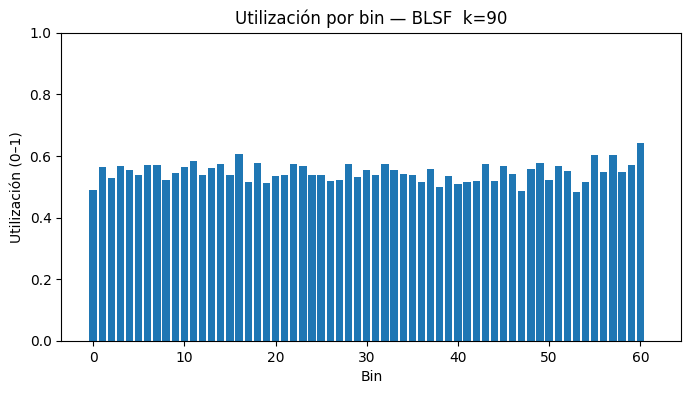

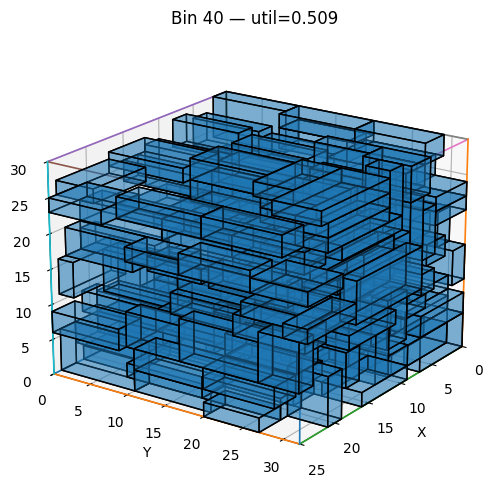

In [4]:
# === Resumen por bin + gráficas (barras y 3D) ===
import os
os.chdir(r"C:\Users\jaime\OneDrive - Universidad de la Sabana\Desktop\Jaime Pesca\MIT\GCLOG\Capstone project\SIMPAC-2024-311-main - 2 - testing")

from deeppack3d import deeppack3d
import math
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# ---- Parámetros de corrida ----
METHOD = 'blsf'              # <--- CAMBIADO: antes era 'rl'
K = 90
DATA_MODE = 'file'         # usamos tu archivo de datos
PATH = './Input_worst_div10_ceil.txt'       # asegúrate de que este archivo exista ahí
N_ITERS = 200              # solo se usa si DATA_MODE == 'generated'
SEED = 42                  # solo se usa si DATA_MODE == 'generated'

# (Opcional) tamaño del contenedor/pallet (W,H,D)
CONTAINER_SIZE = None      # None => se infiere por bounding box

# ---- Recolectar colocaciones por bin ----
bins = []               # lista de bins; cada bin es una lista de items
current_bin_items = None

gen_kwargs = dict(data=DATA_MODE, verbose=0)
if DATA_MODE == 'file':
    gen_kwargs['path'] = PATH
else:
    gen_kwargs['n_iterations'] = N_ITERS
    gen_kwargs['seed'] = SEED

for result in deeppack3d(METHOD, K, **gen_kwargs):
    if result is None:
        # empieza un nuevo bin
        current_bin_items = []
        bins.append(current_bin_items)
        continue
    bin_id, (x,y,z), (w,h,d), meta = result
    if current_bin_items is None:
        current_bin_items = []
        bins.append(current_bin_items)
    current_bin_items.append((x,y,z,w,h,d))

num_bins = len(bins)
print(f"🧱 Bins detectados: {num_bins}")

# ---- Utilidad por bin ----
def bin_utilization(items, container_size=None):
    """Devuelve (utilizacion, used_volume, container_volume, (W,H,D) usado)"""
    if not items:
        return 0.0, 0.0, 0.0, (0,0,0)
    used_volume = sum(w*h*d for (_,_,_,w,h,d) in items)
    if container_size is None:
        # inferir por bounding box de lo empacado
        max_x = max(x+w for (x,y,z,w,h,d) in items)
        max_y = max(y+h for (x,y,z,w,h,d) in items)
        max_z = max(z+d for (x,y,z,w,h,d) in items)
        W,H,D = max_x, max_y, max_z
    else:
        W,H,D = container_size
    container_volume = max(1, W*H*D)  # evita div/0
    return (used_volume / container_volume, used_volume, container_volume, (W,H,D))

utilizations = []
sizes_used = []
for i, items in enumerate(bins):
    u, used_v, cont_v, sz = bin_utilization(items, CONTAINER_SIZE)
    utilizations.append(u)
    sizes_used.append(sz)
    print(f"Bin {i}: util={u:.3f}  used_vol={used_v:.0f}  cont_vol={cont_v:.0f}  size={sz}")

# ---- Gráfico de barras: utilización por bin ----
plt.figure(figsize=(8,4))
plt.bar(range(len(utilizations)), utilizations)
plt.xlabel("Bin")
plt.ylabel("Utilización (0–1)")
plt.title(f"Utilización por bin — {METHOD.upper()}  k={K}")
plt.ylim(0, 1.0)
plt.show()

# ---- 3D del bin que elijas ----
BIN_TO_PLOT = 40  # cambia el índice para ver otro bin

def draw_cuboid(ax, x, y, z, w, h, d, alpha=0.35):
    # Si por algún error vino una caja "vacía", no la dibujes
    if w <= 0 or h <= 0 or d <= 0:
        return

    X = [x, x+w]; Y = [y, y+h]; Z = [z, z+d]
    faces = [
        [(X[0],Y[0],Z[0]), (X[1],Y[0],Z[0]), (X[1],Y[1],Z[0]), (X[0],Y[1],Z[0])],
        [(X[0],Y[0],Z[1]), (X[1],Y[0],Z[1]), (X[1],Y[1],Z[1]), (X[0],Y[1],Z[1])],
        [(X[0],Y[0],Z[0]), (X[1],Y[0],Z[0]), (X[1],Y[0],Z[1]), (X[0],Y[0],Z[1])],
        [(X[0],Y[1],Z[0]), (X[1],Y[1],Z[0]), (X[1],Y[1],Z[1]), (X[0],Y[1],Z[1])],
        [(X[0],Y[0],Z[0]), (X[0],Y[1],Z[0]), (X[0],Y[1],Z[1]), (X[0],Y[0],Z[1])],
        [(X[1],Y[0],Z[0]), (X[1],Y[1],Z[0]), (X[1],Y[1],Z[1]), (X[1],Y[0],Z[1])],
    ]
    poly = Poly3DCollection(faces, edgecolor='k', alpha=alpha)
    ax.add_collection3d(poly)

def get_axis_limits(items, fallback=(1,1,1)):
    if not items:
        return (0,1),(0,1),(0,1)
    max_x = max(x+w for (x,y,z,w,h,d) in items)
    max_y = max(y+h for (x,y,z,w,h,d) in items)
    max_z = max(z+d for (x,y,z,w,h,d) in items)
    return (0, max(max_x, fallback[0])), (0, max(max_y, fallback[1])), (0, max(max_z, fallback[2]))

items = bins[BIN_TO_PLOT] if BIN_TO_PLOT < num_bins else []
(W,H,D) = sizes_used[BIN_TO_PLOT] if BIN_TO_PLOT < num_bins else (1,1,1)

fig = plt.figure(figsize=(6,6))
ax = fig.add_subplot(111, projection='3d')

# dibuja contenedor solo con líneas (sin Poly3DCollection para evitar el bug)
def draw_container_wire(ax, W,H,D):
    edges = [
        ((0,0,0),(W,0,0)), ((W,0,0),(W,H,0)),
        ((W,H,0),(0,H,0)), ((0,H,0),(0,0,0)),
        ((0,0,D),(W,0,D)), ((W,0,D),(W,H,D)),
        ((W,H,D),(0,H,D)), ((0,H,D),(0,0,D)),
        ((0,0,0),(0,0,D)), ((W,0,0),(W,0,D)),
        ((W,H,0),(W,H,D)), ((0,H,0),(0,H,D)),
    ]
    for (x1,y1,z1),(x2,y2,z2) in edges:
        ax.plot([x1,x2],[y1,y2],[z1,z2], linewidth=1.2)

# dibuja contenedor inferido o indicado
draw_container_wire(ax, W,H,D)

# dibuja cajas (limita cantidad si hay muchas)
for (x,y,z,w,h,d) in items[:300]:
    draw_cuboid(ax, x,y,z,w,h,d, alpha=0.35)

# ejes
(xmin,xmax),(ymin,ymax),(zmin,zmax) = get_axis_limits(items, (W,H,D))
ax.set_xlim(xmin, xmax); ax.set_ylim(ymin, ymax); ax.set_zlim(zmin, zmax)
ax.set_xlabel('X'); ax.set_ylabel('Y'); ax.set_zlabel('Z')
ax.view_init(elev=20, azim=35)
plt.title(f"Bin {BIN_TO_PLOT} — util={utilizations[BIN_TO_PLOT]:.3f}")
plt.show()


### Pruebas RL

In [1]:
import os
import numpy as np
import tensorflow as tf

from env import MultiBinPackerEnv
from conveyor import FileConveyor
from agent import Agent
from split_gen import reset_rng  # para el RNG global que usa el proyecto


In [2]:
# Configuración
BIN_SIZE   = (25, 32, 30)                 # tu bin
LOOKAHEAD  = 10                           # k
DATA_PATH  = "Input_worst_div10_ceil.txt" # pon la ruta correcta a tu txt
SEED       = 42

# Semillas para reproducibilidad
reset_rng(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

# Crear entorno con tu tamaño de bin
env = MultiBinPackerEnv(
    n_bins=1,
    max_bins=1,
    size=BIN_SIZE,
    k=LOOKAHEAD,
    prealloc_items=0,   # no usamos generador aleatorio
    verbose=True,
    shuffle=False
)

# Reemplazar el conveyor por tu FileConveyor
env.conveyor = FileConveyor(k=LOOKAHEAD, path=DATA_PATH).reset()

# Comprobar que lee bien los items
print("Primeros items del archivo:")
print(env.conveyor.peek())


Primeros items del archivo:
[(10, 2, 3), (10, 6, 2), (10, 3, 2), (10, 3, 2), (10, 3, 3), (9, 3, 3), (7, 5, 2), (10, 5, 2), (10, 5, 2), (10, 6, 2)]


In [3]:
# Crear agente en modo entrenamiento
agent = Agent(
    env=env,
    train=True,
    verbose=True,
    visualize=False,
    batch_size=32
)

# Hiperparámetros
NUM_EPISODES = 200          # cambia según quieras
MODEL_DIR    = "models"
MODEL_NAME   = f"bin_{BIN_SIZE[0]}x{BIN_SIZE[1]}x{BIN_SIZE[2]}_k{LOOKAHEAD}_mis_datos.h5"
MODEL_PATH   = os.path.join(MODEL_DIR, MODEL_NAME)

os.makedirs(MODEL_DIR, exist_ok=True)

# Exploración inicial
agent.eps = 1.0

print(f"Entrenando {NUM_EPISODES} episodios con lookahead={LOOKAHEAD}, bin={BIN_SIZE} y datos de '{DATA_PATH}'...\n")

# Agent.run es un generador; lo recorremos para ejecutar todos los episodios
for _ in agent.run(max_ep=NUM_EPISODES, verbose=False, train=True):
    # cada yield es una colocación o None al final de un episodio; no necesitamos usarlo aquí
    pass

print("\n✅ Entrenamiento terminado.")

# Guardar el modelo
agent.q_net.save(MODEL_PATH)
print(f"🧠 Modelo guardado en: {MODEL_PATH}")

# Métricas básicas
utils   = [u for utils, n_bins, ep_reward in agent.ep_history for u in utils]
rewards = [ep_reward for utils, n_bins, ep_reward in agent.ep_history]

print(f"Episodios entrenados: {len(agent.ep_history)}")
print(f"Utilización media: {np.mean(utils)*100:.2f}%")
print(f"Recompensa media por episodio: {np.mean(rewards):.4f}")


Entrenando 200 episodios con lookahead=10, bin=(25, 32, 30) y datos de 'Input_worst_div10_ceil.txt'...

bin 0, loc: 0, space util: 65.83, packed items: 226

Episode 0, util: [65.82], used bins: 1, ep_reward: 139.77, memory: 226, eps: 1.00, loss: None, lr: 9.999999747378752e-06
bin 0, loc: 0, space util: 67.79, packed items: 235

update model
fit done, epoch 1, loss=0.3354
Episode 1, util: [67.79], used bins: 1, ep_reward: 142.66, memory: 461, eps: 1.00, loss: 0.33537691831588745, lr: 9.999999747378752e-06
bin 0, loc: 0, space util: 63.86, packed items: 220

update model
fit done, epoch 2, loss=0.0816
Episode 2, util: [63.86], used bins: 1, ep_reward: 136.66, memory: 681, eps: 1.00, loss: 0.08164897561073303, lr: 9.999999747378752e-06
bin 0, loc: 0, space util: 66.16, packed items: 227

update model
fit done, epoch 3, loss=0.2005
Episode 3, util: [66.16], used bins: 1, ep_reward: 138.48, memory: 908, eps: 1.00, loss: 0.20054014027118683, lr: 9.999999747378752e-06
bin 0, loc: 0, space ut

c:\Users\jaime\anaconda3\envs\deeppack3d\lib\site-packages\keras\src\engine\training.py:3000: UserWarning: You are saving your model as an HDF5 file via `model.save()`. This file format is considered legacy. We recommend using instead the native Keras format, e.g. `model.save('my_model.keras')`.
  saving_api.save_model(


🧠 Modelo guardado en: models\bin_25x32x30_k10_mis_datos.h5
Episodios entrenados: 200
Utilización media: 64.58%
Recompensa media por episodio: 136.9784


In [4]:
from env import MultiBinPackerEnv
from conveyor import FileConveyor
from agent import Agent
import tensorflow as tf

# Recrear el entorno igual que en entrenamiento
env_test = MultiBinPackerEnv(
    n_bins=1,
    max_bins=1,
    size=BIN_SIZE,
    k=LOOKAHEAD,
    prealloc_items=0,
    verbose=True,
    shuffle=False
)
env_test.conveyor = FileConveyor(k=LOOKAHEAD, path=DATA_PATH).reset()

test_agent = Agent(env=env_test, train=False, verbose=True, visualize=False, batch_size=32)
test_agent.q_net = tf.keras.models.load_model(MODEL_PATH, compile=False)
test_agent.eps = 0.0  # greedy

TEST_EPISODES = 10

for _ in test_agent.run(max_ep=TEST_EPISODES, verbose=False, train=False):
    pass

utils_test = [u for utils, n_bins, ep_reward in test_agent.ep_history for u in utils]
print(f"Utilización media en test: {np.mean(utils_test)*100:.2f}%")


bin 0, loc: 0, space util: 67.72, packed items: 236

Episode 0, util: [67.72], used bins: 1, ep_reward: 143.63, memory: None, eps: 0.00, loss: None, lr: None
bin 0, loc: 0, space util: 67.72, packed items: 236

Episode 1, util: [67.72], used bins: 1, ep_reward: 143.63, memory: None, eps: 0.00, loss: None, lr: None
bin 0, loc: 0, space util: 67.72, packed items: 236

Episode 2, util: [67.72], used bins: 1, ep_reward: 143.63, memory: None, eps: 0.00, loss: None, lr: None
bin 0, loc: 0, space util: 67.72, packed items: 236

Episode 3, util: [67.72], used bins: 1, ep_reward: 143.63, memory: None, eps: 0.00, loss: None, lr: None
bin 0, loc: 0, space util: 67.72, packed items: 236

Episode 4, util: [67.72], used bins: 1, ep_reward: 143.63, memory: None, eps: 0.00, loss: None, lr: None
bin 0, loc: 0, space util: 67.72, packed items: 236

Episode 5, util: [67.72], used bins: 1, ep_reward: 143.63, memory: None, eps: 0.00, loss: None, lr: None
bin 0, loc: 0, space util: 67.72, packed items: 236
